# Sentiment Analysis of IMDB Movie Reviews

## Purpose

This notebook aims to perform sentiment analysis on IMDB movie reviews. The process involves:

1.  **Data Loading and Initial Exploration:** Loading the dataset and getting a first look at the data.
2.  **Text Preprocessing:** Cleaning the raw text data by removing HTML tags, punctuation, converting to lowercase, removing stopwords, and lemmatizing.
3.  **Exploratory Data Analysis (EDA):** Analyzing word frequencies, common words in positive and negative reviews, and visualizing with word clouds.
4.  **Feature Engineering:** Converting text data into numerical features using CountVectorizer and TF-IDF.
5.  **Model Building:** Developing an Artificial Neural Network (ANN) using Keras for sentiment classification.
6.  **Model Evaluation:** Assessing the performance of the trained ANN model.

In [ ]:
import kagglehub
rajathmc_bag_of_words_meets_bags_of_popcorn__path = kagglehub.dataset_download('rajathmc/bag-of-words-meets-bags-of-popcorn-')
aayushkubba_mask_image_path = kagglehub.dataset_download('aayushkubba/mask-image')

print('Data source import complete.')

100%|██████████| 52.4M/52.4M [00:00<00:00, 55.8MB/s]

Extracting files...


100%|██████████| 327k/327k [00:00<00:00, 66.7MB/s]

Extracting files...
Data source import complete.


## 1. Data Loading and Initial Exploration

This section focuses on loading the IMDB movie review dataset and performing initial checks to understand its structure and content.

In [ ]:
!ls /root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/

labeledTrainData.tsv  testData.tsv
sampleSubmission.csv  unlabeledTrainData.tsv


In [ ]:
rajathmc_bag_of_words_meets_bags_of_popcorn__path

'/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1'

The dataset contains movie reviews along with their sentiment (positive/negative). We will load the `labeledTrainData.tsv` file, which is tab-separated.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/1.complete
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/testData.tsv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/sampleSubmission.csv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/unlabeledTrainData.tsv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/labeledTrainData.tsv


In [ ]:
train=pd.read_csv("/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/labeledTrainData.tsv",delimiter="\t")
train.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


### Sample Review

Let's inspect a sample review to understand the raw text format before preprocessing.

In [ ]:
# Sample Review
train["review"][20]

'\\Soylent Green\\" is one of the best and most disturbing science fiction movies of the 70\'s and still very persuasive even by today\'s standards. Although flawed and a little dated, the apocalyptic touch and the environmental premise (typical for that time) still feel very unsettling and thought-provoking. This film\'s quality-level surpasses the majority of contemporary SF flicks because of its strong cast and some intense sequences that I personally consider classic. The New York of 2022 is a depressing place to be alive, with over-population, unemployment, an unhealthy climate and the total scarcity of every vital food product. The only form of food available is synthetic and distributed by the Soylent company. Charlton Heston (in a great shape) plays a cop investigating the murder of one of Soylent\'s most eminent executives and he stumbles upon scandals and dark secrets... The script is a little over-sentimental at times and the climax doesn\'t really come as a big surprise, st

## 2. Text Preprocessing

Raw text data often contains noise that needs to be cleaned before it can be used for machine learning. This section outlines the preprocessing steps applied to the movie reviews.

In [ ]:
!pip install nltk
!pip install beautifulsoup4

### Importing Libraries and Downloading NLTK Data

We'll use `nltk` for natural language processing tasks like stopword removal and lemmatization, and `BeautifulSoup` for HTML tag removal. First, we need to install and import these libraries, and download necessary NLTK data.

In [ ]:
import re
import nltk
from bs4 import BeautifulSoup

In [ ]:
nltk.download("all")


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

### Initializing Stopwords and Lemmatizer

We initialize the English stopwords list from NLTK and a WordNet Lemmatizer to reduce words to their base forms.

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
stopwords=stopwords.words("english")
wordnet_lemma=WordNetLemmatizer()

### Preprocessing Function

The `preprocess_text` function performs the following steps:

1.  **Remove HTML tags:** Uses `BeautifulSoup` to strip out any HTML tags present in the review.
2.  **Remove non-alphabetic characters:** Keeps only letters, replacing other characters (numbers, punctuation) with spaces.
3.  **Lowercase conversion:** Converts all text to lowercase to ensure consistency.
4.  **Stopword removal:** Removes common words (like 'a', 'the', 'is') that do not carry much sentiment information.
5.  **Lemmatization:** Reduces words to their base or root form (e.g., 'running' to 'run', 'better' to 'good').

In [ ]:
review = train['review'][0]

In [ ]:
review

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [ ]:
def preprocess_text(review):
    # Remove all HTML tags
    review= BeautifulSoup(review).get_text()

    # Remove anything which is not a character
    review=re.sub("[^a-zA-Z]"," ",review)

    #Lowercase
    review=review.lower()

    # Stopword
    review = " ".join([i for i in review.split() if i not in stopwords])


    # Lemmatizer
    review = " ".join([wordnet_lemma.lemmatize(i) for i in review.split()])

    return review

### Preprocessing Demonstration

Let's see how the `preprocess_text` function transforms a sample review.

In [ ]:
review=review = train['review'][0]
print("Original Text: ")
print(review)
print("_"*25)
cleaned_review= preprocess_text(review)
print("Cleaner Text: ")
print(cleaned_review)

Original Text: 
With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when

### Applying Preprocessing to the Dataset

Now, we apply the `preprocess_text` function to the entire 'review' column of our training dataset to create a new 'clean_review' column.

In [ ]:
# Apply this function over full dataframe

train['clean_review']=train['review'].apply(preprocess_text)

## 3. Exploratory Data Analysis (EDA) on Cleaned Text

This section explores the cleaned text data to understand word distributions, common terms, and differences between positive and negative reviews.

In [ ]:
# Give me list of all words frequency
train.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,stuff going moment mj started listening music ...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",classic war world timothy hines entertaining f...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,film start manager nicholas bell giving welcom...
3,3630_4,0,It must be assumed that those who praised this...,must assumed praised film greatest filmed oper...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy wondrously unpretentious explo...


### Word Frequency Analysis

We will calculate the frequency of each word in the entire corpus and identify the most common words.

In [ ]:
freq_list={}
for review in train['clean_review'].tolist():
    for word in review.split():
        freq_list[word]=freq_list.get(word,0)+1

In [ ]:
# Give 10 most frequent words

# Sort freq_list dictionary
sorted_freq_words=dict(sorted(freq_list.items(), key= lambda item:item[1], reverse=True))

### Sentiment-Specific Word Frequencies

To understand what words are more characteristic of positive or negative reviews, we calculate word frequencies separately for each sentiment category.

In [ ]:
from collections import Counter
cnt = Counter(" ".join(train['clean_review'].tolist()).split())


In [ ]:
pos_cnt = Counter(" ".join(train.loc[train['sentiment']==1]['clean_review'].tolist()).split())
neg_cnt = Counter(" ".join(train.loc[train['sentiment']==0]['clean_review'].tolist()).split())

### Most Frequent Words in Positive and Negative Reviews
Understanding which words are prevalent in positive versus negative reviews can provide insights into sentiment indicators.

In [ ]:
pos_cnt.most_common(10)

[('film', 24745),
 ('movie', 22657),
 ('one', 14169),
 ('like', 9270),
 ('time', 8346),
 ('good', 7762),
 ('story', 7478),
 ('character', 7073),
 ('well', 6488),
 ('great', 6435)]

In [ ]:
neg_cnt.most_common(10)

[('movie', 29037),
 ('film', 22289),
 ('one', 13572),
 ('like', 11470),
 ('even', 7684),
 ('time', 7613),
 ('good', 7435),
 ('bad', 7394),
 ('character', 7104),
 ('would', 7036)]

### Word Cloud Visualization

A word cloud visually represents word frequencies, where larger words appear more frequently. We'll generate a word cloud for all cleaned reviews, excluding 'film' and 'movie' as they are very common but not necessarily sentiment-indicative.

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
wordcloud = WordCloud(stopwords=["film","movie"],
                      width=800,
                      height=400,
                      background_color='white').generate(" ".join(train['clean_review'].tolist()))

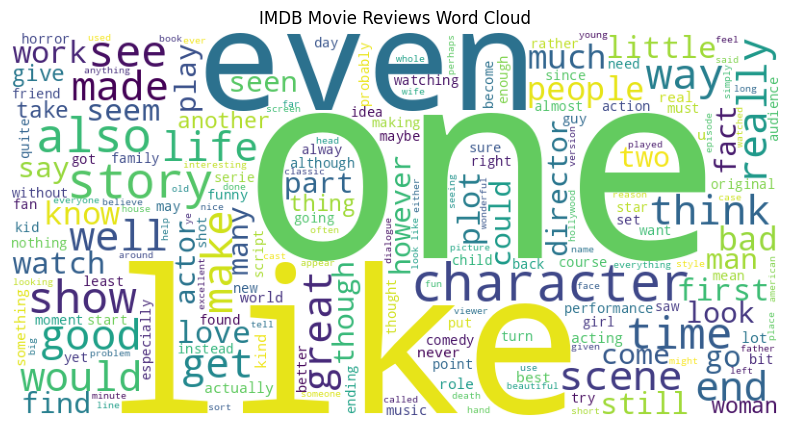

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("IMDB Movie Reviews Word Cloud")
plt.show()

## 4. Feature Engineering: Vectorization

Machine learning models cannot directly process raw text. Feature engineering involves converting text into numerical representations (vectors). We will use two popular techniques: CountVectorizer and TF-IDF Vectorizer.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
train.columns

Index(['id', 'sentiment', 'review', 'clean_review'], dtype='object')

### Data Splitting

Before vectorization, we split our data into training and testing sets to evaluate our model's performance on unseen data. The `clean_review` column will be our features (`X`) and `sentiment` will be our target variable (`y`).

In [ ]:
X=train['clean_review']
y=train['sentiment']

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### CountVectorizer

`CountVectorizer` converts a collection of text documents to a matrix of token counts. Each row represents a document, and each column represents a unique word in the vocabulary, with the cell value being the count of that word in the document.

In [ ]:
def create_vector(vectorizer,data):
    '''Pass vectorizer and data'''
    train_vector=vectorizer.transform(data.tolist())
    return train_vector.toarray()

We initialize a `CountVectorizer` to consider the 1000 most frequent words. Then, we fit it on the training data and transform both training and testing sets.

In [ ]:
len(cnt)

66507

In [ ]:
vectorizer=CountVectorizer(max_features=1000)

In [ ]:
vectorizer.fit(X_train.tolist())

CountVectorizer(max_features=1000)

### TF-IDF Vectorizer

TF-IDF (Term Frequency-Inverse Document Frequency) is another common technique. It not only considers how many times a word appears in a document (Term Frequency) but also how unique or rare the word is across all documents (Inverse Document Frequency). This helps to give more weight to important words and less to common words like 'the' or 'a'.

In [ ]:
X_train_vector=create_vector(vectorizer,X_train)
X_test_vector=create_vector(vectorizer,X_test)

In [ ]:
X_train_vector.shape

(16750, 1000)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

We initialize a `TfidfVectorizer` to consider the 2000 most frequent words, using NLTK's word tokenizer and English stopwords. We fit it on the training data and transform both training and testing sets.

In [ ]:
tf_vectorizer = TfidfVectorizer(analyzer="word",
                                tokenizer=nltk.word_tokenize,
                                preprocessor=None,
                                stop_words='english',
                                max_features=2000)

In [ ]:
tf_vectorizer.fit(X_train.tolist())

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TfidfVectorizer(max_features=2000, stop_words='english',
                tokenizer=<function word_tokenize at 0x7d649882b7e0>)

In [ ]:
X_train_tfvector=create_vector(tf_vectorizer,X_train)
X_test_tfvector=create_vector(tf_vectorizer,X_test)

In [ ]:
X_test_tfvector.shape, X_train_tfvector.shape

((8250, 2000), (16750, 2000))

## 5. Model Building: Artificial Neural Network (ANN) with Keras

We will build a simple Artificial Neural Network (ANN) using Keras to classify the sentiment of movie reviews. The model will take the TF-IDF vectorized text features as input.

In [ ]:
from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

### ANN Model Architecture

The model consists of several dense layers with ReLU activation, followed by dropout layers for regularization to prevent overfitting. The final output layer uses a sigmoid activation for binary classification (positive or negative sentiment).

In [ ]:
model_ann = Sequential()
# Input layer with the number of features from X_train_tfvector
model_ann.add(Dense(units=128, activation='relu', input_shape=(X_train_tfvector.shape[1],)))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=64, activation='relu'))
model_ann.add(Dropout(0.3))
model_ann.add(Dense(units=32, activation='relu'))
model_ann.add(Dropout(0.3))
# Output layer for binary classification
model_ann.add(Dense(units=1, activation='sigmoid'))
model_ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,497 (1.02 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

The model is compiled with the `adam` optimizer, `binary_crossentropy` loss function (suitable for binary classification), and `accuracy` as the evaluation metric.

In [ ]:
model_ann.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

### Model Training

The model is trained using the `X_train_tfvector` features and `y_train` labels. We train for 10 epochs with a batch size of 32, and monitor performance on the validation data (`X_test_tfvector`, `y_test`).

In [ ]:
history = model_ann.fit(X_train_tfvector, y_train, epochs=10, batch_size=32, validation_data=(X_test_tfvector, y_test))

Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8125 - loss: 0.4127 - val_accuracy: 0.8675 - val_loss: 0.3129
Epoch 2/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8857 - loss: 0.2847 - val_accuracy: 0.8648 - val_loss: 0.3151
Epoch 3/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9149 - loss: 0.2236 - val_accuracy: 0.8618 - val_loss: 0.3358
Epoch 4/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9500 - loss: 0.1437 - val_accuracy: 0.8550 - val_loss: 0.4027
Epoch 5/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9733 - loss: 0.0805 - val_accuracy: 0.8531 - val_loss: 0.5419
Epoch 6/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9840 - loss: 0.0470 - val_accuracy: 0.8525 - val_loss: 0.6355
Epoch 7/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9891 - loss: 0.0344 - val_accuracy: 0.8493 - val_loss: 0.6897
Epoch 8/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9907 - loss: 0.0257 - val_accuracy: 0.

## 6. Model Evaluation

After training, we evaluate the ANN model's performance on the test set to assess its generalization ability. We will look at the loss and accuracy metrics.

258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8496 - loss: 0.7866
Test Loss: 0.7866
Test Accuracy: 0.8496


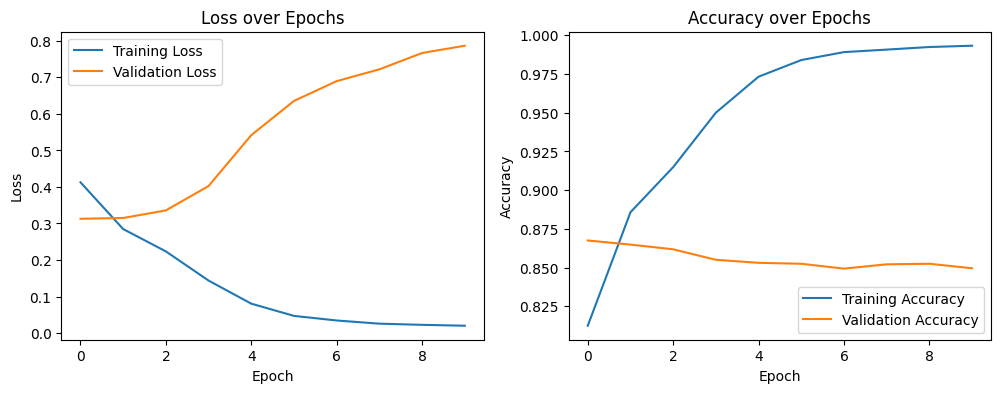

In [ ]:
loss, accuracy = model_ann.evaluate(X_test_tfvector, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# checking the dataset for balance or not
y.value_counts()

,count
sentiment,
1,12500
0,12500


In [ ]:
from keras.layers import LSTM

In [ ]:
model = Sequential()

model.add(LSTM(units =64, activation='relu', return_sequences=True, input_shape = (1, X_train_tfvector.shape[1])))
model.add(Dropout(0.3))
model.add(LSTM(units =32, activation='relu', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units =18, activation='relu', return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 1, 64)          │       528,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 1, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 18)             │         3,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,747 (2.08 MB)

 Trainable params: 544,747 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.keras', monitor='val_loss', save_best_only=True)

In [ ]:
X_train_tfvector_reshaped = X_train_tfvector.reshape(X_train_tfvector.shape[0], 1, X_train_tfvector.shape[1])
X_test_tfvector_reshaped = X_test_tfvector.reshape(X_test_tfvector.shape[0], 1, X_test_tfvector.shape[1])

In [ ]:
history_1 = model.fit(X_train_tfvector_reshaped,
                      y_train,
                      epochs=50,
                      batch_size=32,
                      validation_data=(X_test_tfvector_reshaped, y_test),
                      callbacks=[early_stopping, model_checkpoint])

Epoch 1/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7707 - loss: 0.4881 - val_accuracy: 0.8701 - val_loss: 0.3139
Epoch 2/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8750 - loss: 0.3121 - val_accuracy: 0.8674 - val_loss: 0.3133
Epoch 3/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8890 - loss: 0.2790 - val_accuracy: 0.8601 - val_loss: 0.3340
Epoch 4/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8986 - loss: 0.2538 - val_accuracy: 0.8634 - val_loss: 0.3342
Epoch 5/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9073 - loss: 0.2325 - val_accuracy: 0.8623 - val_loss: 0.3623
Epoch 6/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9204 - loss: 0.2050 - val_accuracy: 0.8594 - val_loss: 0.3758
Epoch 7/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9353 - loss: 0.1745 - val_accuracy: 0.8525 - val_loss: 0.4514


258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8708 - loss: 0.3070
Test Loss: 0.3070
Test Accuracy: 0.8708


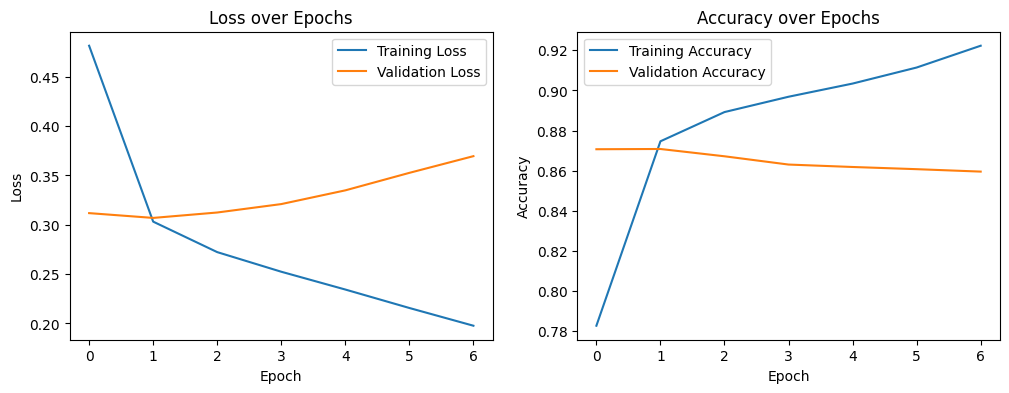

In [ ]:
loss, accuracy = model.evaluate(X_test_tfvector_reshaped, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()